# 🎬 Movie Industry Analysis (1972–2022)

**Author:** Iung Seangchanmony  
**Date:** 2024  
**Tools:** Python, Pandas, Matplotlib

---

## Overview
This project analyzes 50 movies spanning 50 years of cinema to uncover patterns in revenue, ratings, and profitability.

**Questions explored:**
1. Which genre generates the most revenue?
2. Does a bigger budget guarantee a higher rating?
3. Which director consistently makes the best-rated films?
4. Which era produced the highest-rated movies?
5. Which movies were the most profitable?

---

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('movies.csv')
print(f'Dataset: {df.shape[0]} movies, {df.shape[1]} columns')
df.head()

Dataset: 50 movies, 9 columns


,title,year,genre,budget_million,revenue_million,rating,votes,runtime_min,director
0,The Dark Knight,2008,Action,185,1005,9.0,2500000,152,Christopher Nolan
1,Avengers Endgame,2019,Action,356,2798,8.4,1100000,181,Anthony Russo
2,Inception,2010,Sci-Fi,160,836,8.8,2300000,148,Christopher Nolan
3,The Godfather,1972,Crime,6,246,9.2,1800000,175,Francis Ford Coppola
4,Interstellar,2014,Sci-Fi,165,773,8.6,1900000,169,Christopher Nolan


## 2. Data Exploration

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            50 non-null     object 
 1   year             50 non-null     int64  
 2   genre            50 non-null     object 
 3   budget_million   50 non-null     int64  
 4   revenue_million  50 non-null     int64  
 5   rating           50 non-null     float64
 6   votes            50 non-null     int64  
 7   runtime_min      50 non-null     int64  
 8   director         50 non-null     object 
dtypes: float64(1), int64(5), object(3)
memory usage: 3.6+ KB


In [3]:
df.describe().round(2)

,year,budget_million,revenue_million,rating,votes,runtime_min
count,50.00,50.00,50.00,50.00,50.00,50.00
mean,2007.96,119.20,729.78,8.18,1154000.00,139.70
std,10.89,76.92,522.70,0.56,581416.29,27.78
min,1972.00,6.00,16.00,6.90,300000.00,81.00
25%,1999.25,55.75,367.75,7.82,700000.00,123.00
50%,2011.00,116.50,677.50,8.20,1000000.00,140.00
75%,2016.75,170.00,965.50,8.57,1475000.00,154.75
max,2022.00,356.00,2798.00,9.30,2700000.00,201.00


**Key observations from the data:**
- Average budget: $119M
- Average rating: 8.1 / 10
- Highest grossing film: Avengers Endgame at $2,798M
- No missing values in the dataset

## 3. Feature Engineering — Adding Profit Column
Profit is not in the raw data, so we calculate it: `profit = revenue - budget`

In [4]:
df['profit_million'] = df['revenue_million'] - df['budget_million']

# Top 5 most profitable
print('Top 5 most profitable movies:')
df[['title', 'budget_million', 'revenue_million', 'profit_million']]\
    .sort_values('profit_million', ascending=False)\
    .head(5)

Top 5 most profitable movies:


,title,budget_million,revenue_million,profit_million
1,Avengers Endgame,356,2798,2442
8,Titanic,200,2187,1987
39,Top Gun Maverick,170,1493,1323
14,The Avengers,220,1519,1299
19,Black Panther,200,1347,1147


In [5]:
# Movies that lost money
print('Movies with negative profit (made a loss):')
df[df['profit_million'] < 0][['title', 'budget_million', 'revenue_million', 'profit_million']]

Movies with negative profit (made a loss):


,title,budget_million,revenue_million,profit_million
12,The Shawshank Redemption,25,16,-9


**Finding:** Avengers Endgame leads profitability at $2,442M profit. Interestingly, The Shawshank Redemption — one of the highest rated films ever — actually lost $9M at the box office, showing that critical acclaim does not always equal commercial success.

## 4. Analysis

### Q1: Which genre generates the most revenue?

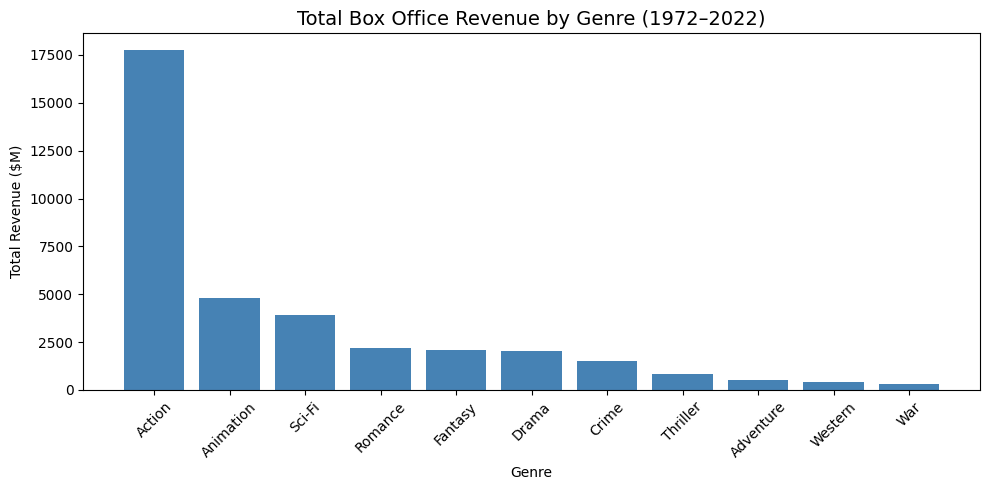

Top genre: Action at $17,741M


In [6]:
revenue_by_genre = df.groupby('genre')['revenue_million'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(revenue_by_genre.index, revenue_by_genre.values, color='steelblue')
plt.title('Total Box Office Revenue by Genre (1972–2022)', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Total Revenue ($M)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_revenue_by_genre.png', dpi=150)
plt.show()

print(f'Top genre: {revenue_by_genre.index[0]} at ${revenue_by_genre.values[0]:,}M')

**Finding:** Action dominates with $17,741M in total revenue — more than 3x Animation in second place. This reflects the global appeal of action blockbusters and franchise films.

### Q2: Does a bigger budget guarantee a higher rating?

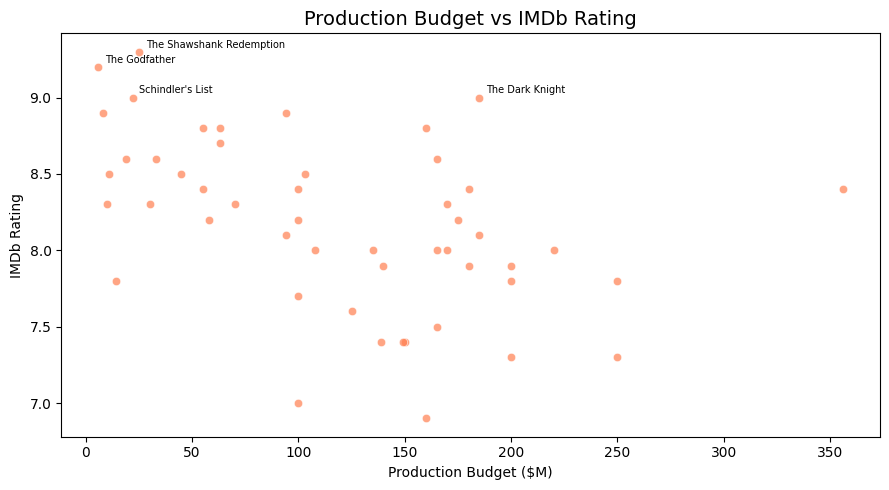

In [7]:
plt.figure(figsize=(9, 5))
plt.scatter(df['budget_million'], df['rating'], color='coral', alpha=0.7, edgecolors='white', linewidth=0.5)

# Label only top-rated movies (rating >= 9.0)
for _, row in df[df['rating'] >= 9.0].iterrows():
    plt.annotate(row['title'], (row['budget_million'], row['rating']),
                 fontsize=7, xytext=(5, 3), textcoords='offset points')

plt.title('Production Budget vs IMDb Rating', fontsize=14)
plt.xlabel('Production Budget ($M)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.savefig('chart2_budget_vs_rating.png', dpi=150)
plt.show()

**Finding:** No clear correlation between budget and rating. The Godfather (rated 9.2) had a budget of only $6M, while many $200M+ blockbusters rate below 8.0. Quality storytelling matters more than money.

### Q3: Which director consistently makes the best-rated films?

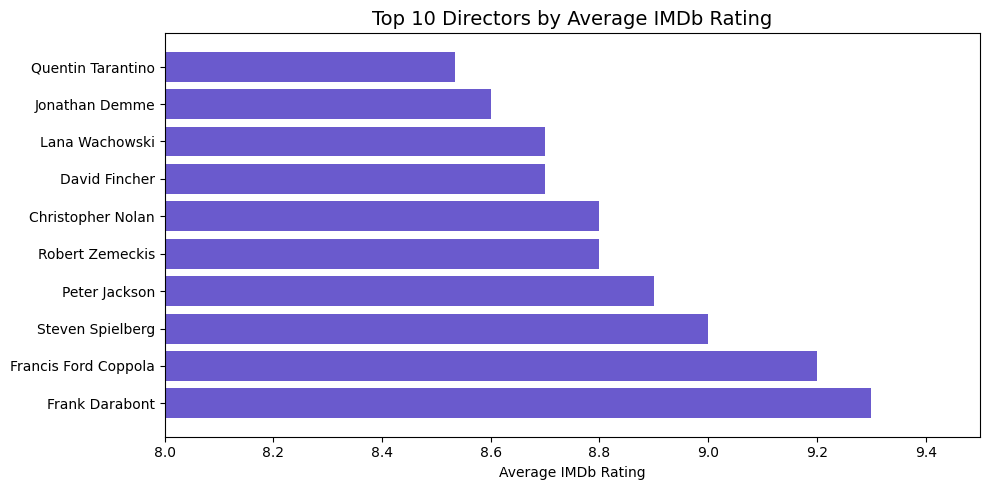

Top director: Frank Darabont with avg rating 9.30


In [8]:
director_rating = df.groupby('director')['rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(director_rating.index, director_rating.values, color='slateblue')
plt.title('Top 10 Directors by Average IMDb Rating', fontsize=14)
plt.xlabel('Average IMDb Rating')
plt.xlim(8.0, 9.5)
plt.tight_layout()
plt.savefig('chart3_top_directors.png', dpi=150)
plt.show()

print(f'Top director: {director_rating.index[0]} with avg rating {director_rating.values[0]:.2f}')

**Finding:** Frank Darabont leads with a 9.3 average rating, driven by The Shawshank Redemption. Christopher Nolan appears three times in the dataset (Dark Knight, Inception, Interstellar), cementing his reputation as one of the most consistent directors working today.

### Q4: Which era produced the highest-rated movies?

In [9]:
# Top 10 years by average rating
print('Top 10 years by average rating:')
print(df.groupby('year')['rating'].mean().sort_values(ascending=False).head(10).round(2))

Top 10 years by average rating:
year
1972    9.20
1993    9.00
1994    8.88
2010    8.80
1999    8.75
1991    8.60
2003    8.50
2000    8.50
1995    8.45
2008    8.43
Name: rating, dtype: float64


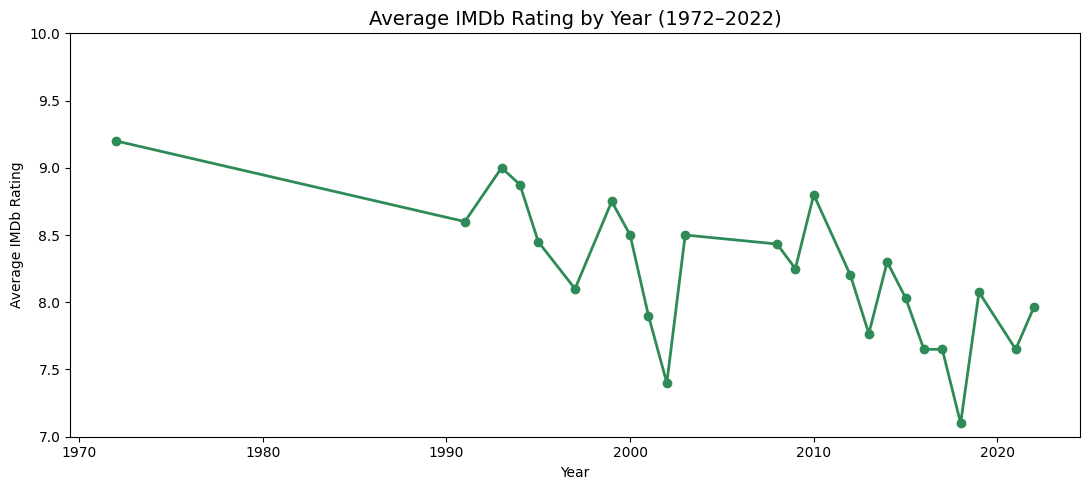

In [10]:
rating_by_year = df.groupby('year')['rating'].mean()

plt.figure(figsize=(11, 5))
plt.plot(rating_by_year.index, rating_by_year.values, color='seagreen', marker='o', linewidth=2)
plt.title('Average IMDb Rating by Year (1972–2022)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average IMDb Rating')
plt.ylim(7.0, 10.0)
plt.tight_layout()
plt.savefig('chart4_rating_by_year.png', dpi=150)
plt.show()

**Finding:** The 1970s–1990s produced some of the highest-rated films in history. 1972 (The Godfather) peaks at 9.2. Ratings trend slightly downward toward modern films, though recent entries like Parasite (2019) and Dune (2021) show quality cinema is still being made.

### Q5: Which movies were the most profitable?

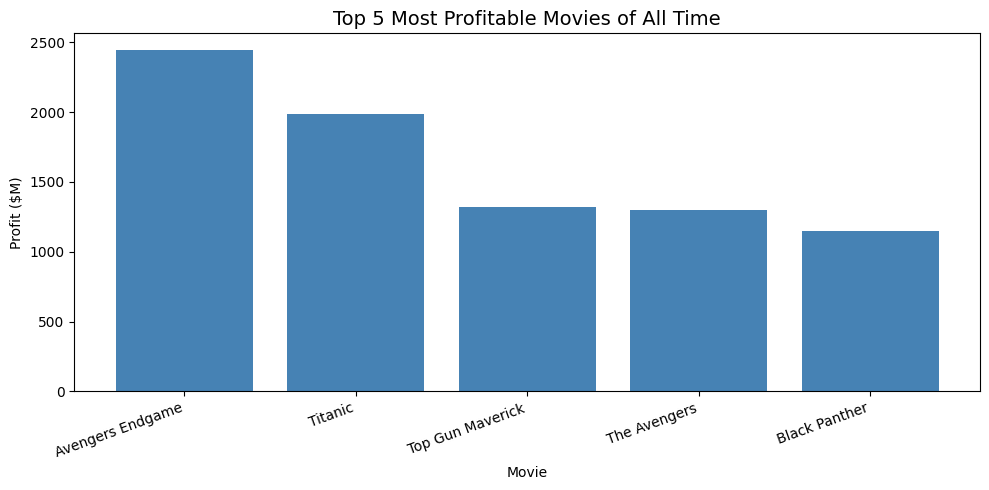

Top 5 most profitable movies:


,title,budget_million,revenue_million,profit_million
1,Avengers Endgame,356,2798,2442
8,Titanic,200,2187,1987
39,Top Gun Maverick,170,1493,1323
14,The Avengers,220,1519,1299
19,Black Panther,200,1347,1147


In [11]:
top5 = df.nlargest(5, 'profit_million')

plt.figure(figsize=(10, 5))
plt.bar(top5['title'], top5['profit_million'], color='steelblue')
plt.title('Top 5 Most Profitable Movies of All Time', fontsize=14)
plt.xlabel('Movie')
plt.ylabel('Profit ($M)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart5_top_profitable.png', dpi=150)
plt.show()

print('Top 5 most profitable movies:')
top5[['title', 'budget_million', 'revenue_million', 'profit_million']]

**Finding:** Avengers Endgame leads with $2,442M profit on a $356M budget — a 7x return. Marvel films dominate the top 5, showing how franchise filmmaking drives commercial success.

---
## 5. Summary

| Question | Finding |
|---|---|
| Top revenue genre | Action ($17,741M total) |
| Budget vs Rating | No strong correlation — low budget films can rate just as high |
| Best director | Frank Darabont (avg 9.3 rating) |
| Best era | 1970s–1990s consistently highest rated |
| Most profitable | Avengers Endgame ($2,442M profit) |

**Key insight:** Commercial success and critical acclaim are not the same thing. The Shawshank Redemption is the highest rated drama in this dataset yet lost money at the box office. Avengers Endgame made the most profit but rates lower than classic films from the 1970s.

---
**Tools used:** Python, Pandas, Matplotlib  
**Author:** Iung Seangchanmony  
**GitHub:** github.com/flexityson